# Import

In [ ]:
import os
import gc
import random
from tqdm import tqdm, trange

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from scipy import signal

import torch
from torch import tensor
from torch.optim import RMSprop, Adam, NAdam, SGD, Adamax, Adadelta, AdamW, LBFGS, Adagrad
from torch.utils.data import random_split, DataLoader
from torch.nn.functional import normalize
# from torch.utils.data import Dataset, TensorDataset

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import shap
import pickle

from IPython.display import clear_output, Image as IPImage, display
import time

# Config

In [ ]:
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
INTENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

DATA_DIR = 'Datasets/'
CP_DIR = 'Checkpoints/'
LOG_DIR = 'Log/'


torch.cuda.empty_cache()
gc.collect()

from torch import nn

class Config:
    EXPERIMETS = datasets = [
        "Mona Lisa",
        "Necker cube"
        ]
    RHYTHMS = signal_fiq = [
        'alpha',
        'beta',
        'delta',
        'gamma',
        'theta'
        ]
    MODELS = [
        'Big',
        'Small',
        'CNN'
        ]
    OPTIMIZER_LIST = [
        'Adadelta',
        'Adagrad',
        'Adam',
        'Adamax',
        'AdamW',
        'NAdam',
        'RMSprop',
        'SGD'
        ]
    signal_name = signal_fiq
    batch_size = 50
    threshold = 0.001
    seed = 42
    n_folds = 10
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device('cpu')
    epochs = 100
    in_features = 15000
    out_features  = 6400
    activation=nn.ReLU()
    loss_func = nn.CrossEntropyLoss()
    lr_patience = 5
    lr = 1e-5
    save_best_model = False

print(Config.device)

def set_seed(seed = 42):
    torch.initial_seed() % 2**32
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)
    gseed = torch.Generator().manual_seed(seed)
    # print(worker_seed)
    return gseed

set_seed(Config.seed)

# Robiul preparation

In [60]:
class EEG:
    def __init__(self, participant,datasets):

        self.int = {}
        self.delta = {}
        self.theta = {}
        self.alpha = {}
        self.beta = {}
        self.gamma = {}

        for dataset in datasets:
            if dataset == "Mona Lisa":
                Dname = "/Figs for spectra"
                var1 = "/Backgr_int_"
                var2 = ".dat"
            else:
                Dname = "/Cubes for spectra"
                var1 = "/Backgr_int_"
                var2 = "_type_0.4.dat"

        for intensity in INTENSITIES:
            S = os.path.join(base, "Participant " + str(participant) + Dname + var1 + str(intensity) + var2)
            I = intensity
            self.int[I] = np.loadtxt(S)
            delta_signal = np.empty(self.int[I].shape)
            theta_signal =  np.empty(self.int[I].shape)
            alpha_signal = np.empty(self.int[I].shape)
            beta_signal = np.empty(self.int[I].shape)
            gamma_signal = np.empty(self.int[I].shape)

            for c in range(self.int[I].shape[1]):
                delta_signal[:,c], theta_signal[:,c],alpha_signal[:, c], beta_signal[:, c],gamma_signal[:,c] = self.fir_filtering(I, c)
            self.delta[I] = delta_signal
            self.theta[I] = theta_signal
            self.alpha[I] = alpha_signal
            self.beta[I] = beta_signal 
            self.gamma[I] = gamma_signal

    def fir_filtering(self, I, c):
        filter_delta = signal.firwin(400, [1.0, 4.0], pass_zero=False, fs=250)
        filter_theta = signal.firwin(400, [5.0, 8.0], pass_zero=False, fs=250)
        filter_alpha = signal.firwin(400, [8.0, 12.0], pass_zero=False, fs=250)
        filter_beta = signal.firwin(400, [13.0, 30.0], pass_zero=False, fs=250)
        filter_gamma = signal.firwin(400, [31.0, 45.0], pass_zero=False, fs=250)
        res_delta = signal.convolve(self.int[I][:, c], filter_delta, mode='same')
        res_theta = signal.convolve(self.int[I][:, c], filter_theta, mode='same')
        res_alpha = signal.convolve(self.int[I][:, c], filter_alpha, mode='same')
        res_beta = signal.convolve(self.int[I][:, c], filter_beta, mode='same')
        res_gamma = signal.convolve(self.int[I][:, c], filter_gamma, mode='same')
        
        return res_delta,res_theta, res_alpha,res_beta,res_gamma 

In [5]:
Intencity = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
file_path = os.path.join(base, "Channels.dat")
df_channels = pd.read_csv(file_path, header=None, sep='.')
channel_names = df_channels.iloc[:, -1:].values.flatten()

def convart_sin_fiq(fiq):
  if fiq == 'delta':
    return 1
  elif fiq == 'theta':
    return 2
  elif fiq == 'alpha':
    return 3
  elif fiq =='beta': 
    return 4
  elif fiq == 'gamma':
    return 5

def createdataframe(user,dataset,signal_fiq):
    global Intencity,channel_names
    tem_signal = []
    eeg_person = EEG(user,dataset)
    for i in Intencity:
        for ch in range(0,31):
            tem = [dataset,ch,channel_names[ch],convart_sin_fiq(signal_fiq),signal_fiq,i,user]
            # tem = [channel_names[ch]]
            S = 'tem_signal.append(np.append(tem, eeg_person.'+signal_fiq+'.get(i)[:,ch][0:15000]))'
            eval(S)
    
           
    tem_dataframe = pd.DataFrame(tem_signal)

    colunm = [] 

    colunm.append("Dataset")
    colunm.append("channel")
    colunm.append("Channel_Name")
    colunm.append("band")
    colunm.append("frequency")
    colunm.append("Intencity")
    colunm.append("participant")

    for col in range(0,15000):
      S = 'Time'+str(col)
      colunm.append(S)    
    
    
    
    tem_dataframe.columns  = colunm 
    return tem_dataframe

# Dataset

In [62]:
df = DataFrame()

for experiment in Config.EXPERIMETS:
    for rhythm in Config.RHYTHMS:
        participants = trange(1, 11, leave=True)
        for user in participants:
            df = pd.concat([df, createdataframe(user, experiment, rhythm)], ignore_index=True)
            participants.set_postfix(rhythm=rhythm, user=user, counts=len(df),  experiment=experiment, refresh=True)

 20%|██        | 2/10 [00:16<01:06,  8.37s/it, counts=620, experiment=Mona Lisa, rhythm=alpha, user=2]


KeyboardInterrupt: 

In [ ]:
df

In [ ]:
dataset = DatasetDict()
splits = df['frequency'].unique()

for split in tqdm(splits):
    # dataset = DatasetDict(
    #     {split: Dataset.from_pandas(df[df['frequency'] == split])}
    # )
    dataset[split] = Dataset.from_pandas(df[df['frequency'] == split], split=split)

print(dataset)

In [ ]:
dataset.save_to_disk('test')

In [ ]:
# df.to_csv('dataframe.csv')
# df = pd.read_csv('dataframe.csv', index_col=0)

In [ ]:
# dataset = Dataset.from_pandas(df)
dataset.save_to_disk(DATA_DIR)

## Loading

In [8]:
dataset = load_from_disk(DATA_DIR)

In [9]:
df = dataset['beta'].to_pandas()
tdf = df.iloc[:, 7:]
tdf.drop(columns='__index_level_0__', inplace=True)

In [10]:
dataset

DatasetDict({
    alpha: Dataset({
        features: ['Dataset', 'channel', 'Channel_Name', 'band', 'frequency', 'Intencity', 'participant', 'Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86',

## Spectrogram

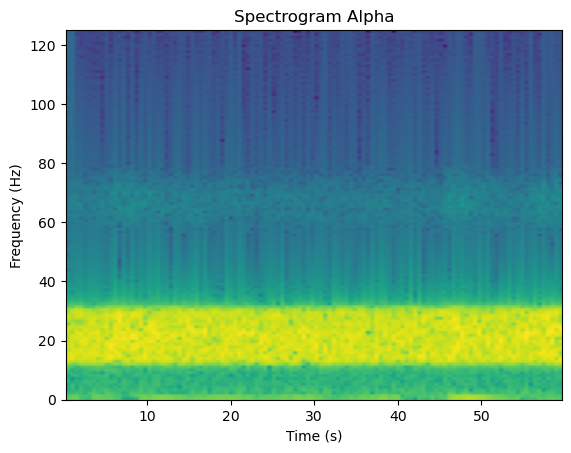

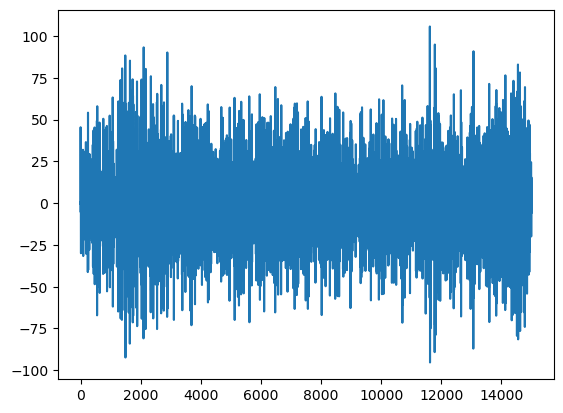

In [12]:
data = tdf.iloc[5].values
data = data.astype(float) 

fig, (ax1) = plt.subplots(nrows=1, sharex=True)

plt.specgram(data.T, Fs=250, cmap="viridis")
plt.title('Spectrogram Alpha')
plt.xlabel("DATA")
plt.ylabel("TIME")
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()
plt.plot(data)

## Split

In [13]:
df = dataset['beta'].to_pandas()
df.drop(columns='__index_level_0__', inplace=True)
tdf = df.iloc[:]['Channel_Name']
_tdf = df.iloc[:, 7:]
# tdf.drop(columns='__index_level_0__', inplace=True)

In [14]:
temp = pd.concat([tdf,_tdf], axis=1)

In [15]:
_tdf.reset_index(drop=True, inplace=True)

In [16]:
temp.set_index('Channel_Name')

,Time0,Time1,Time2,Time3,Time4,Time5,Time6,Time7,Time8,Time9,...,Time14990,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999
Channel_Name,,,,,,,,,,,,,,,,,,,,,
O2-A2,7.898202825189966,142.88122843837667,236.61433897177037,262.91947708104243,218.6206413777391,123.41669862714858,11.224591966222876,-83.14246351507417,-136.37115284432664,-143.25597556607036,...,-38.18538561624355,-30.38504351660704,-10.75610552015229,12.40143078347081,29.634895270603074,34.4525564671636,25.984250405021402,9.026975453515032,-8.445742466567188,-19.070241826129752
O1-A1,-20.661551768279033,-3.3178888938537865,15.86067753030928,31.2603072389248,38.253675655680006,34.88827334475443,22.62031241163489,5.761847565643105,-10.158089773009896,-20.45395090241714,...,7.7870476180727275,-5.507603568925836,-14.78782399029838,-17.43558536768065,-13.694727988560164,-6.102808574721513,1.9258190774640624,7.619455848478791,9.773892110448452,8.762393086236592
P4-A2,-3.41998290146831,45.8839271586405,80.01636725388839,90.5881616325705,77.71478145855427,49.19564252862473,16.733360200291422,-9.061738008361983,-22.685675355176883,-25.12576258570995,...,-40.52351449687055,-35.786263357211524,-20.486154096711303,-0.8815437178080274,15.903915943673683,24.740989372333868,24.283072589617632,16.97422012578808,7.417198197417711,-0.024459182983166183
P3-A1,-8.474842975341737,29.743809470806184,57.796062224261185,68.0995833243668,59.420256820695585,36.89565307352701,9.621840505238323,-13.108130669082415,-25.303666883977183,-26.09668500116504,...,-6.858042629424794,-15.04344539915943,-16.031107492025143,-10.839016114708349,-2.9568844684676474,3.5129118801081383,5.822577047639671,3.704570918994044,-0.8231377593642435,-4.765599068662592
C4-A2,12.337216957423825,11.222600555732516,4.820974973563832,-4.428368160765661,-12.634251479343938,-16.052199463279404,-12.706753030664403,-3.3404134984312703,8.744570306585754,18.908580291239478,...,-16.62534465332586,-10.616037180733485,1.381206883417935,15.417854985005373,26.524305163087256,30.522046338567904,25.5553945635357,12.766072292052428,-4.111916403663322,-20.073534231231317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TP7-A1,2.1296883073107895,-33.5622626178618,-60.25737412134718,-71.74787167732488,-66.61392254767412,-48.04575415356499,-22.161927165417882,4.33064931243147,26.14751694713718,40.428991233546014,...,7.462059568981985,8.46826634903286,9.417394659038095,10.315181623232363,10.72578247621584,9.966556169143146,7.462854137696368,3.0801057264641116,-2.721528881186188,-8.96430995559355
CP3-A1,-13.124200069247525,-38.16569529843848,-51.958494946940306,-51.31356844947407,-38.004174542571896,-17.60071218578443,3.046220205271545,18.49336032340349,26.40145747852857,27.630980033730793,...,17.043006817245967,11.839232793691437,6.786784707736707,3.112080272133092,0.9094898245219198,-0.6074823703753225,-2.4593665852492137,-5.227480377796098,-8.696379954224014,-11.953015081912199
Cpz-A1,-18.16484472887774,-52.471322114291866,-72.14176185833188,-71.94660468893647,-53.41140196130678,-23.787135333405935,7.088143057900296,30.610174029333756,42.27872685596029,42.52052997740208,...,8.350173552691082,12.420965277003916,15.428227028622757,15.457536040785953,11.136292990435734,2.4730682794652097,-8.75972307399229,-19.38387543652064,-25.86996126486484,-25.694959939934705


In [17]:
ds = Dataset.from_pandas(temp)

In [18]:
t1 = ds.remove_columns("Channel_Name")
t1

Dataset({
    features: ['Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86', 'Time87', 'Time88', 'Time89', 'Time90', 'Time91', 'Time92', 'Time93', 'Time94', 'Time95', 'Time96', 'Time97', 'Time

In [20]:
#torch.tensor(t1, dtype=torch.float64, device='cuda')

TypeError: must be real number, not dict

## Load

In [ ]:
DATASET = load_from_disk(dataset_path=DATA_DIR)

In [ ]:
from sklearn.calibration import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_from_disk, Dataset
# import datasets

from torch.utils.data.dataset import Dataset


class CustomDataset(Dataset):
    def __init__(self, experiment: str, signal: str, dataset = DATASET, normalize = None, batch_size=Config.batch_size):

        super(CustomDataset, self).__init__()
        self.batch_size = batch_size

        # self.dataset = dataset['alpha'][5]

        # self.dataframe = pd.DataFrame.from_dict(self.dataset)
        # print(self.dataframe)


        self.dataset = dataset[signal].remove_columns('__index_level_0__')
        self.dataframe = self.dataset.to_pandas()
        self.dataframe = self.dataframe[self.dataframe['Dataset'] == experiment]
        self.normalize = normalize
        # self.tensors = self.get_tensors()

        self.X_df = self.X_df()
        self.y_df = self.y_df()

        self.generator_seed = set_seed(Config.seed)

        self.train, self.val, self.test = self.train_val_test()

        self.train_dataloader = self.train_dataloader()
        self.val_dataloader = self.val_dataloader()
        self.test_dataloader = self.test_dataloader()

    def __len__(self):
        return len(self.dataframe)

    # def __getitem__(self, idx):
    #     return self.tensor[idx]+1
    
    def shape(self):
        return self.tensor.shape
    
    def size(self) -> int:
        return super().__sizeof__(self.__len__(), *self.__getitem__(0)[0].shape)

    # def get_tensors(self):
    #     label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
    #     t_label =  torch.tensor(label, dtype=torch.float)
    #     _time = self.dataframe.iloc[:, 7:].to_numpy()
    #     t_time = torch.tensor(_time, dtype=torch.float)
    #     if self.normalize:
    #         t_time = normalize(t_time, p=2, dim = 0).float()   
    #     return TensorDataset(t_label, t_time)
    
    def X_df(self):
        return self.dataframe.iloc[:, 7:]
    
    def y_df(self):

        # Ваш список классов
        classes = [' O2-A2', ' O1-A1', ' P4-A2', ' P3-A1', ' C4-A2', ' C3-A1',
                ' F4-A2', ' F3-A1', ' Fp2-A2', ' Fp1-A1', ' T6-A2', ' T5-A1',
                ' T4-A2', ' T3-A1', ' F8-A2', ' F7-A1', ' Oz-A2', ' Pz-A1',
                ' Cz-A2', ' Fz-A1', ' Fpz-A2', ' FT7-A1', ' FC3-A1', ' Fcz-A1',
                ' FC4-A2', ' FT8-A2', ' TP7-A1', ' CP3-A1', ' Cpz-A1', ' CP4-A2',
                ' TP8-A2']

        # Создаем DataFrame из списка классов
        # df = pd.DataFrame(classes, columns=['Class'])

        # Создаем объект LabelEncoder
        label_encoder = LabelEncoder()

        # Применяем LabelEncoder к столбцу 'Class'
        # self.dataframe['Class_encoded'] = label_encoder.fit_transform(self.dataframe['Channel_Name'])

        label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))

        # label = self.dataframe['Class_encoded']
        return label
    
    def train_val_test(self):
        self.dataframe['Stratify'] = self.dataframe['Channel_Name'].astype(str) + '_' + self.dataframe['Intencity'].astype(str)

        train_x, val_x, train_y, val_y = train_test_split(self.X_df, self.y_df,
                                            test_size=0.2,
                                            shuffle=True,
                                            stratify=self.dataframe['Stratify'],
                                            ) 
        val_x, test_x, val_y, test_y, = train_test_split(val_x, val_y,
                                            test_size=0.5,
                                            shuffle=True,
                                            stratify=val_y,
                                            )
        

        # x = normalize(torch.tensor(test_x.values, dtype=torch.float), p=2, dim = 0) 
        # print(x[0][0].item())
        # train_x.reset_index(drop=True, inplace=True)
        # val_x.reset_index(drop=True, inplace=True)
        # test_x.reset_index(drop=True, inplace=True)
        # train_y.reset_index(drop=True, inplace=True)
        # val_y.reset_index(drop=True, inplace=True)
        # test_y.reset_index(drop=True, inplace=True)

        # x_train = normalize(torch.tensor(train_x.values, dtype=torch.float), p=1, dim = 1)
        # x_val = normalize(torch.tensor(val_x.values, dtype=torch.float), p=1, dim = 1)
        # x_test = normalize(torch.tensor(test_x.values, dtype=torch.float), p=1, dim = 1)

        train_x = torch.tensor(train_x.values.astype(float), dtype=torch.float)
        val_x = torch.tensor(val_x.values.astype(float), dtype=torch.float)
        test_x = torch.tensor(test_x.values.astype(float), dtype=torch.float)


        train_x_y = TensorDataset(train_x, torch.tensor(train_y.values.astype(float), dtype=torch.long))
        val_x_y = TensorDataset(val_x, torch.tensor(val_y.values.astype(float), dtype=torch.long))
        test_x_y = TensorDataset(test_x, torch.tensor(test_y.values.astype(float), dtype=torch.long))

        return train_x_y, val_x_y, test_x_y
    
    def train_dataloader(self):
        train_dataloader = DataLoader(self.train, batch_size=self.batch_size, shuffle=True, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return train_dataloader
    
    def val_dataloader(self):
        val_dataloader = DataLoader(self.val, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return val_dataloader
    
    def test_dataloader(self):
        test_dataloader = DataLoader(self.test, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return test_dataloader

# Model

In [ ]:
import os
import random
import numpy as np
import torch.nn as nn

class RobiulModel(nn.Module):

    def __init__(self,
                model_name = 'Small',
                experiment = Config.EXPERIMETS[0],
                rhythm = Config.RHYTHMS[0],
                optimizer = Config.OPTIMIZER_LIST[0],
                in_features = Config.in_features,
                out_features = Config.out_features,
                lr = Config.lr,
                batch_size = Config.batch_size,
                shap_mode = False,
                ):
        
        super(RobiulModel, self).__init__()

        gc.collect()
        if Config.device == 'cuda': torch.cuda.empty_cache()
        self.shap_mode = shap_mode
        self.dataset =  CustomDataset(experiment=experiment, signal=rhythm, batch_size=batch_size)
        self.config(in_features, out_features)
        self.activation = Config.activation
        self.model_name = model_name
        self.experiment = experiment
        self.rhythm = rhythm
        self.optimizer = optimizer
        self.lr = lr
        self.batch_size = batch_size
        self.best_epoch = 0
        self.best_val_acc = 0
        self.best_test_acc = 0
        self.threshold = 0.5
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = Config.epochs
        self.lr_hist = []
        self.best_loss = None
        self.count = 0
        self.test_loss = []
        self.test_acc = []

        self.X_cr = []
        self.roc_lr_probs = []
    

        if model_name == 'Big':
            self.lr = 1e-2
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 1000, bias=False),
                self.activation,
                nn.BatchNorm1d(1000),
                nn.Linear(1000, 500, bias=False),
                self.activation,
                nn.BatchNorm1d(500),
                nn.Linear(500, 200, bias=False),
                self.activation,
                nn.BatchNorm1d(200),
                nn.Linear(200, 100, bias=False),
                self.activation,
                nn.BatchNorm1d(100),
                nn.Linear(100, 50, bias=False),
                self.activation,
                nn.BatchNorm1d(50),
                nn.Linear(50, 25, bias=False),
                self.activation,
                nn.BatchNorm1d(25),
                nn.Linear(25, 15, bias=False),
                self.activation,
                nn.BatchNorm1d(15),
                nn.Linear(15, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                # self.activation,
                # nn.BatchNorm1d(1),
                nn.Sigmoid(),
            )
        elif model_name == 'Small':
            self.lr = 1e-5
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                nn.Sigmoid(),
                
            )            
        elif model_name == 'CNN':
            self.lr = 1e-3
            self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            )

            self.cnn_linear = nn.Sequential(
                nn.Linear(240000, self.batch_size),
                nn.LeakyReLU(inplace=True),
                nn.Linear(self.batch_size, 2),
            )

        self = self.to(Config.device)
        self.settings()        
        self.metrics_dir = f"{LOG_DIR}{self.model_name}_{self.experiment.replace(' ', '_')}_{self.rhythm}_{self.optimizer.__class__.__name__}/"        

    
    def forward(self, x):
        if self.model_name == 'CNN':
            x = x.unsqueeze(1)
            x = self.cnn(x)
            x = x.view(x.size(0), -1)
            x = self.cnn_linear(x)
            return x
        else:
            if self.shap_mode:
                x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device(Config.device))
            logits = self.linear_stack(x)
            logits = logits.squeeze()
            return logits
    
    def config(self,
        in_features = Config.in_features,
        out_features = Config.out_features):
        self.in_features = in_features
        self.out_features = out_features
    
    def settings(self):
        self.loss_func = Config.loss_func
        
        if self.optimizer == 'NAdam':
            self.optimizer = NAdam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'SGD':
            self.optimizer = SGD(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adam':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'AdamW':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'RMSprop':
            self.optimizer = RMSprop(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adamax':
            self.optimizer = Adamax(self.parameters(), lr=self.lr)  
        elif self.optimizer == 'LBFGS':
            self.optimizer = LBFGS(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adadelta':
            self.optimizer = Adadelta(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adagrad':
            self.optimizer = Adagrad(self.parameters(), lr=self.lr)            

        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=self.optimizer,
                                                                mode='min',
                                                                patience=Config.lr_patience,
                                                                # threshold=Config.threshold,
                                                                threshold_mode='rel',
                                                                # cooldown=0,
                                                                min_lr=0,
                                                                # eps=1e-8,
                                                                )
        
    def fit(self):   
        self.start_time = time.time()
        for epoch in range(self.epochs):
            train_loop = tqdm(self.dataset.train_dataloader, leave=False)
            train_loss = 0.0
            correct = 0
            self.train()
            for batch in train_loop:
                self.optimizer.zero_grad()
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    # print(targets.shape,'\n', pred.shape)
                    # print(targets, '\n', pred)
                    # targets = targets.long()
                    # loss = self.loss_func(pred, targets)
                    loss = self.loss_func(pred, targets.to(torch.long))
                 
                    pred = pred.argmax(dim=1)
                    # print(targets.shape,'\n', pred.shape)                    
                    predicted_classes = (pred >= self.threshold).to(torch.int)                
                else:
                    targets = targets.to(torch.float) 
                    loss = self.loss_func(pred, targets)    
                    predicted_classes = (pred >= self.threshold).to(torch.int)

                loss.backward()
                self.optimizer.step()

                # running_train_loss.append(loss)
                train_loss += loss.item() * targets.size(0)  # Суммируем потери, умноженные на размер батча

                mean_train_loss = train_loss / len(self.dataset.train_dataloader.sampler)

                # print(predicted_classes.shape, targets.shape)

                # true_answers += sum(predicted_classes == targets)

                train_loop.set_description(f'Epoch: [{epoch+1}/{self.epochs}]')
               
                correct += torch.eq(predicted_classes, targets).sum().item()

                running_train_acc = correct / len(self.dataset.train)

            self.train_loss.append(mean_train_loss)
            self.train_acc.append(running_train_acc)

            self.eval()
            val_loss = 0.0
            with torch.no_grad():

                # running_val_loss = []
                correct = 0

                for batch in self.dataset.val_dataloader:

                    X = batch[0].to(Config.device)
                    targets = batch[1].to(Config.device)

                    pred = self(X)

                    # print(X.shape, pred.shape, targets.shape)

                    if self.model_name == 'CNN':
                        loss = self.loss_func(pred, targets.to(torch.long))
                        pred = pred.argmax(dim=1)
                        predicted_classes = (pred >= self.threshold).to(torch.int)  
                    else:
                        # print(X.shape, pred.shape, targets.shape)
                        # print(X, pred, targets)
                        # pred = torch.round(pred)
                        # pred = pred.argmax(dim=0)
                        loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                        predicted_classes = (pred >= self.threshold).to(torch.int)

                    # running_val_loss.append(loss.item())
                    # mean_val_loss = sum(running_val_loss) / len(running_val_loss)

                    val_loss += loss.item() * targets.size(0)
                    val_size = len(self.dataset.val_dataloader.sampler)
                    mean_val_loss = val_loss / val_size 

                    # true_answers += sum(predicted_classes == targets)
                    # max_values, _ = torch.max(tensor, dim=1, keepdim=True)

                    # print(pred.shape, targets.shape)
                    # print(X.shape, pred.shape, targets.shape)
                    # print(X, pred, targets)

                    correct += torch.eq(predicted_classes, targets).sum().item()
            # break
            running_val_acc = correct / len(self.dataset.val) # true_answers / len(train_dataset.val)

            self.val_loss.append(mean_val_loss)
            self.val_acc.append(running_val_acc)

            self.lr_scheduler.step(mean_val_loss)
            lr = self.lr_scheduler.get_last_lr()[0]
            self.lr_hist.append(lr)

            print(f'Epoch: [{epoch+1}/{self.epochs}] | train_loss = [{mean_train_loss:.4f}] : train_acc = [{running_train_acc:.4f}] : val_loss = [{mean_val_loss:.4f}] : val_acc = [{running_val_acc:.4f}] : lr = [{lr}]')

            if self.best_loss is None:
                self.best_loss = mean_val_loss
            
            if self.best_loss > mean_val_loss:

                # Save best model
                print(f'Find best loss=[{self.best_loss}], model saved on {epoch+1} epoch')                
                if Config.save_best_model:
                    if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)                       
                    torch.save(self.state_dict(), f'{self.metrics_dir}best_model.pt')                
                self.count = 0
                self.best_loss = mean_val_loss
                self.end_time = time.time()
                self.best_epoch = epoch+1
                self.best_train_acc = running_train_acc
                self.best_val_acc = running_val_acc
                self.fLR = lr

            if self.count >= Config.n_folds:
                print(f"\033[31m Finished on {epoch+1} epoch. \033[0m")
                break

            self.count += 1

    def test(self):
        self.eval()
        with torch.no_grad():

            running_test_loss = []
            correct = 0

            self.inference_start_time = time.time()
            for batch in self.dataset.test_dataloader:
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    loss = self.loss_func(pred, targets.to(torch.long))
                    self.X_cr.append(pred.argmax(1))
                    self.roc_lr_probs.append(pred.argmax(1))                    
                    predicted_classes = (pred.argmax(1) >= self.threshold).to(torch.int)
                else:
                    loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                    predicted_classes = (pred >= self.threshold).to(torch.int)
                    self.X_cr.append(pred)
                    self.roc_lr_probs.append(pred)                    

                running_test_loss.append(loss.item())
                mean_test_loss = sum(running_test_loss) / len(running_test_loss)

                correct += torch.eq(predicted_classes, targets).sum().float().item()

        running_test_acc = correct / len(self.dataset.test)
        # running_test_acc = true_answers / len(train_dataset.test)

        self.test_loss.append(mean_test_loss)
        self.test_acc.append(running_test_acc)

        print(f'test_loss: [{mean_test_loss:.4f}] : test_acc: [{running_test_acc:.4f}]')

        self.best_test_acc = running_test_acc
        self.inference_end_time = time.time()
        self.save_log()

    def metrics_shap(self,
                     max_samples = 5,
                     time_samples = 1000):
        # max_samples = 5
        # time_samples = 1000
        set_seed(Config.seed)

        shap.initjs()
        X = self.dataset.dataframe
        X = X.iloc[:,7:]
        # X.drop('__index_level_0__', axis=1, inplace=True)

        samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]
        background = samples.iloc[:, :time_samples]
        values = samples.iloc[:, time_samples+1:2*time_samples+1]

        self.__init__('Small', background.shape[1], background.shape[0])
        self.shap_mode = True
        e = shap.Explainer(self, background, max_evals=samples.shape[1]*2+1)
        shap_values = e(values)
        shap.plots.beeswarm(shap_values)

    def save_log(self):

        if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)   
        # ROC AUC
        targets_pred = np.hstack([tensor.detach().cpu() for tensor in self.roc_lr_probs])
        targets_true = self.dataset.test.tensors[1][:len(targets_pred)]
        self.roc_auc = roc_auc_score(targets_true, targets_pred)
        with open(f'{self.metrics_dir}roc_true_dump.pkl', 'wb') as f:
            pickle.dump(targets_true, f)
        with open(f'{self.metrics_dir}roc_pred.pkl', 'wb') as f:
            pickle.dump(targets_pred, f)

        # Classification report
        data = list(map(lambda x: x.cpu().numpy(), self.X_cr))
        y_test_pred = np.array(data).flatten().tolist()
        y_test_pred = list(map(lambda x: round(x), y_test_pred))
        y_test = self.dataset.test.tensors[1][:len(y_test_pred)].numpy().tolist()
        report = classification_report(y_test, y_test_pred, output_dict=True)
        with open(f'{self.metrics_dir}classification_report.pkl', 'wb') as f:
            pickle.dump(report, f)

        # Metrcis
        metrics_df = pd.DataFrame({
            'Model': [self.model_name],
            'Dataset': [self.experiment],
            'Rhythm': [self.rhythm],
            'Optimizer': [self.optimizer.__class__.__name__],
            'Start LR': [self.lr],
            'Final LR': [self.fLR],
            'Epoch': [self.best_epoch],
            'Train Accuracy': [self.best_train_acc],
            'Val Accuracy': [self.best_val_acc],
            'Test Accuracy': [self.best_test_acc],
            'Train Time': [f'{self.end_time - self.start_time:.2f}'],
            'Inference Time': [f'{self.inference_end_time - self.inference_start_time:.2f}'],
            'ROC AUC': [self.roc_auc],
            },)
        csv_file_path = f'{self.metrics_dir}metrics.csv'
        metrics_df.to_csv(csv_file_path, index=False)

        # Metrics loss_acc
        plt.plot(torch.normal(tensor(self.train_loss)).to("cpu"))
        plt.plot(torch.normal(tensor(self.val_loss)).to("cpu"))
        plt.xlabel('Loss train/val')
        plt.savefig(f'{self.metrics_dir}loss.png')
        plt.clf()
        plt.close()
        plt.plot(torch.asarray(self.train_acc).to("cpu"))
        plt.plot(torch.asarray(self.val_acc).to("cpu"))
        plt.xlabel('Accuracy train/val')
        plt.savefig(f'{self.metrics_dir}accuracy.png')
        plt.clf()
        plt.close()

    def metrics_show(self):
        all_dirs =  next(os.walk(LOG_DIR))[1]
        result = pd.DataFrame()
        for dir in all_dirs:
            all_files = os.listdir(LOG_DIR+dir)
            csv_files = [f for f in all_files if f.endswith('metrics.csv')]
            for file in csv_files:
                df = pd.read_csv(LOG_DIR+dir+'/'+file)
                result = pd.concat([result, df], ignore_index=True)
                sorted_df = result.sort_values(by='Test Accuracy', ascending=False)
        return sorted_df

    def reports_show(self):
        all_files = os.listdir(LOG_DIR)
        csv_files = [f for f in all_files if f.endswith('report.csv')]
        # print("Список CSV файлов в папке:")
        # print(csv_files)
        result = pd.DataFrame()
        for file in csv_files:
            df = pd.read_csv(LOG_DIR+file)
            # result = pd.concat([result, df], ignore_index=True)
        return result  

# Tests

In [6]:
for experiment in Config.EXPERIMETS:
    for rhythm in Config.RHYTHMS:
        for model_name in Config.MODELS:
            for optimizer in Config.OPTIMIZER_LIST:
                print(f'{experiment} | {rhythm} | {model_name} | {optimizer}')
                model = RobiulModel(model_name=model_name, experiment=experiment, rhythm=rhythm, optimizer=optimizer, batch_size=100)
                model.fit()
                model.test()              
                clear_output(wait=True)

Necker cube | theta | CNN | SGD


Epoch: [1/100] | train_loss = [2.8930] : train_acc = [0.5823] : val_loss = [1.8720] : val_acc = [0.6032] : lr = [0.001]


Epoch: [2/100] | train_loss = [0.8758] : train_acc = [0.6758] : val_loss = [1.0502] : val_acc = [0.6355] : lr = [0.001]
Find best loss=[1.8719823706534602], model saved on 2 epoch


Epoch: [3/100] | train_loss = [0.6201] : train_acc = [0.7290] : val_loss = [0.7731] : val_acc = [0.6871] : lr = [0.001]
Find best loss=[1.0502161710493025], model saved on 3 epoch


Epoch: [4/100] | train_loss = [0.5403] : train_acc = [0.7722] : val_loss = [0.5716] : val_acc = [0.6903] : lr = [0.001]
Find best loss=[0.7730626483117381], model saved on 4 epoch


Epoch: [5/100] | train_loss = [0.5033] : train_acc = [0.8012] : val_loss = [0.6769] : val_acc = [0.7323] : lr = [0.001]


Epoch: [6/100] | train_loss = [0.4832] : train_acc = [0.8371] : val_loss = [0.7135] : val_acc = [0.7161] : lr = [0.001]


Epoch: [7/100] | train_loss = [0.3918] : train_acc = [0.8516] : val_loss = [0.4261] : val_acc = [0.7677] : lr = [0.001]
Find best loss=[0.5715756262502363], model saved on 7 epoch


Epoch: [8/100] | train_loss = [0.3287] : train_acc = [0.8794] : val_loss = [0.4686] : val_acc = [0.7774] : lr = [0.001]


Epoch: [9/100] | train_loss = [0.3304] : train_acc = [0.8766] : val_loss = [0.6768] : val_acc = [0.8032] : lr = [0.001]


Epoch: [10/100] | train_loss = [0.3875] : train_acc = [0.8976] : val_loss = [0.8656] : val_acc = [0.7806] : lr = [0.001]


Epoch: [11/100] | train_loss = [0.2763] : train_acc = [0.9016] : val_loss = [0.4819] : val_acc = [0.8097] : lr = [0.001]


Epoch: [12/100] | train_loss = [0.2418] : train_acc = [0.9165] : val_loss = [0.6038] : val_acc = [0.8258] : lr = [0.001]


Epoch: [13/100] | train_loss = [0.2091] : train_acc = [0.9258] : val_loss = [0.3632] : val_acc = [0.8484] : lr = [0.001]
Find best loss=[0.4261060491684944], model saved on 13 epoch


Epoch: [14/100] | train_loss = [0.4724] : train_acc = [0.9181] : val_loss = [0.9653] : val_acc = [0.8258] : lr = [0.001]


Epoch: [15/100] | train_loss = [0.2413] : train_acc = [0.9262] : val_loss = [0.7059] : val_acc = [0.8387] : lr = [0.001]


Epoch: [16/100] | train_loss = [0.2016] : train_acc = [0.9363] : val_loss = [0.4885] : val_acc = [0.8355] : lr = [0.001]


Epoch: [17/100] | train_loss = [0.1496] : train_acc = [0.9419] : val_loss = [0.5608] : val_acc = [0.8290] : lr = [0.001]


Epoch: [18/100] | train_loss = [0.1404] : train_acc = [0.9435] : val_loss = [0.3910] : val_acc = [0.8516] : lr = [0.001]


Epoch: [19/100] | train_loss = [0.1144] : train_acc = [0.9484] : val_loss = [0.4577] : val_acc = [0.8452] : lr = [0.0001]


Epoch: [20/100] | train_loss = [0.1095] : train_acc = [0.9536] : val_loss = [0.3036] : val_acc = [0.8484] : lr = [0.0001]
Find best loss=[0.36319765352433725], model saved on 20 epoch


Epoch: [21/100] | train_loss = [0.0796] : train_acc = [0.9565] : val_loss = [0.2892] : val_acc = [0.8548] : lr = [0.0001]
Find best loss=[0.30355255449971846], model saved on 21 epoch


Epoch: [22/100] | train_loss = [0.0747] : train_acc = [0.9589] : val_loss = [0.2810] : val_acc = [0.8613] : lr = [0.0001]
Find best loss=[0.2891997271968472], model saved on 22 epoch


Epoch: [23/100] | train_loss = [0.0744] : train_acc = [0.9593] : val_loss = [0.2783] : val_acc = [0.8581] : lr = [0.0001]
Find best loss=[0.2810437736972686], model saved on 23 epoch


Epoch: [24/100] | train_loss = [0.0722] : train_acc = [0.9613] : val_loss = [0.2765] : val_acc = [0.8548] : lr = [0.0001]
Find best loss=[0.2782591985118005], model saved on 24 epoch


Epoch: [25/100] | train_loss = [0.0716] : train_acc = [0.9617] : val_loss = [0.2752] : val_acc = [0.8548] : lr = [0.0001]
Find best loss=[0.2764625703134844], model saved on 25 epoch


Epoch: [26/100] | train_loss = [0.0703] : train_acc = [0.9617] : val_loss = [0.2745] : val_acc = [0.8548] : lr = [0.0001]
Find best loss=[0.2751672460186866], model saved on 26 epoch


Epoch: [27/100] | train_loss = [0.0695] : train_acc = [0.9617] : val_loss = [0.2728] : val_acc = [0.8548] : lr = [0.0001]
Find best loss=[0.2744787546896165], model saved on 27 epoch


Epoch: [28/100] | train_loss = [0.0683] : train_acc = [0.9621] : val_loss = [0.2720] : val_acc = [0.8581] : lr = [0.0001]
Find best loss=[0.2728090843846721], model saved on 28 epoch


Epoch: [29/100] | train_loss = [0.0681] : train_acc = [0.9625] : val_loss = [0.2728] : val_acc = [0.8581] : lr = [0.0001]


Epoch: [30/100] | train_loss = [0.0670] : train_acc = [0.9633] : val_loss = [0.2721] : val_acc = [0.8581] : lr = [0.0001]


Epoch: [31/100] | train_loss = [0.0659] : train_acc = [0.9629] : val_loss = [0.2716] : val_acc = [0.8581] : lr = [0.0001]
Find best loss=[0.27203046506451023], model saved on 31 epoch


Epoch: [32/100] | train_loss = [0.0653] : train_acc = [0.9629] : val_loss = [0.2710] : val_acc = [0.8581] : lr = [0.0001]
Find best loss=[0.27157199959601125], model saved on 32 epoch


Epoch: [33/100] | train_loss = [0.0644] : train_acc = [0.9633] : val_loss = [0.2713] : val_acc = [0.8613] : lr = [0.0001]


Epoch: [34/100] | train_loss = [0.0642] : train_acc = [0.9637] : val_loss = [0.2707] : val_acc = [0.8613] : lr = [0.0001]
Find best loss=[0.27101198511738933], model saved on 34 epoch


Epoch: [35/100] | train_loss = [0.0626] : train_acc = [0.9633] : val_loss = [0.2710] : val_acc = [0.8613] : lr = [0.0001]


Epoch: [36/100] | train_loss = [0.0623] : train_acc = [0.9629] : val_loss = [0.2700] : val_acc = [0.8613] : lr = [0.0001]
Find best loss=[0.2706890336928829], model saved on 36 epoch


Epoch: [37/100] | train_loss = [0.0615] : train_acc = [0.9633] : val_loss = [0.2689] : val_acc = [0.8613] : lr = [0.0001]
Find best loss=[0.26997364336444485], model saved on 37 epoch


Epoch: [38/100] | train_loss = [0.0607] : train_acc = [0.9637] : val_loss = [0.2691] : val_acc = [0.8613] : lr = [0.0001]


Epoch: [39/100] | train_loss = [0.0600] : train_acc = [0.9633] : val_loss = [0.2685] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.2689124115051762], model saved on 39 epoch


Epoch: [40/100] | train_loss = [0.0592] : train_acc = [0.9641] : val_loss = [0.2683] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.2685167520276962], model saved on 40 epoch


Epoch: [41/100] | train_loss = [0.0588] : train_acc = [0.9637] : val_loss = [0.2681] : val_acc = [0.8613] : lr = [0.0001]
Find best loss=[0.2683280744860249], model saved on 41 epoch


Epoch: [42/100] | train_loss = [0.0578] : train_acc = [0.9641] : val_loss = [0.2677] : val_acc = [0.8613] : lr = [0.0001]
Find best loss=[0.2680930783671717], model saved on 42 epoch


Epoch: [43/100] | train_loss = [0.0570] : train_acc = [0.9637] : val_loss = [0.2671] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.26771240657375706], model saved on 43 epoch


Epoch: [44/100] | train_loss = [0.0561] : train_acc = [0.9637] : val_loss = [0.2670] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.26711525455597906], model saved on 44 epoch


Epoch: [45/100] | train_loss = [0.0564] : train_acc = [0.9637] : val_loss = [0.2667] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.2670101773354315], model saved on 45 epoch


Epoch: [46/100] | train_loss = [0.0559] : train_acc = [0.9633] : val_loss = [0.2666] : val_acc = [0.8677] : lr = [0.0001]
Find best loss=[0.2667045208715623], model saved on 46 epoch


Epoch: [47/100] | train_loss = [0.0545] : train_acc = [0.9637] : val_loss = [0.2661] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.26659855919499553], model saved on 47 epoch


Epoch: [48/100] | train_loss = [0.0546] : train_acc = [0.9637] : val_loss = [0.2663] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [49/100] | train_loss = [0.0541] : train_acc = [0.9637] : val_loss = [0.2662] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [50/100] | train_loss = [0.0534] : train_acc = [0.9637] : val_loss = [0.2667] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [51/100] | train_loss = [0.0526] : train_acc = [0.9641] : val_loss = [0.2661] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.26612719220499836], model saved on 51 epoch


Epoch: [52/100] | train_loss = [0.0525] : train_acc = [0.9637] : val_loss = [0.2664] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [53/100] | train_loss = [0.0520] : train_acc = [0.9637] : val_loss = [0.2661] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [54/100] | train_loss = [0.0510] : train_acc = [0.9645] : val_loss = [0.2661] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [55/100] | train_loss = [0.0502] : train_acc = [0.9645] : val_loss = [0.2665] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [56/100] | train_loss = [0.0507] : train_acc = [0.9641] : val_loss = [0.2664] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [57/100] | train_loss = [0.0494] : train_acc = [0.9649] : val_loss = [0.2656] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.26607661477981076], model saved on 57 epoch


Epoch: [58/100] | train_loss = [0.0496] : train_acc = [0.9633] : val_loss = [0.2660] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [59/100] | train_loss = [0.0486] : train_acc = [0.9645] : val_loss = [0.2655] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.26559617250196393], model saved on 59 epoch


Epoch: [60/100] | train_loss = [0.0488] : train_acc = [0.9637] : val_loss = [0.2659] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [61/100] | train_loss = [0.0479] : train_acc = [0.9637] : val_loss = [0.2656] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [62/100] | train_loss = [0.0476] : train_acc = [0.9637] : val_loss = [0.2653] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.2655221185376567], model saved on 62 epoch


Epoch: [63/100] | train_loss = [0.0470] : train_acc = [0.9641] : val_loss = [0.2651] : val_acc = [0.8677] : lr = [0.0001]
Find best loss=[0.26530730147515574], model saved on 63 epoch


Epoch: [64/100] | train_loss = [0.0465] : train_acc = [0.9641] : val_loss = [0.2655] : val_acc = [0.8645] : lr = [0.0001]


Epoch: [65/100] | train_loss = [0.0464] : train_acc = [0.9641] : val_loss = [0.2653] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [66/100] | train_loss = [0.0453] : train_acc = [0.9645] : val_loss = [0.2645] : val_acc = [0.8677] : lr = [0.0001]
Find best loss=[0.2651489069384913], model saved on 66 epoch


Epoch: [67/100] | train_loss = [0.0456] : train_acc = [0.9649] : val_loss = [0.2645] : val_acc = [0.8677] : lr = [0.0001]
Find best loss=[0.2645196068671442], model saved on 67 epoch


Epoch: [68/100] | train_loss = [0.0445] : train_acc = [0.9641] : val_loss = [0.2641] : val_acc = [0.8645] : lr = [0.0001]
Find best loss=[0.2644834018522693], model saved on 68 epoch


Epoch: [69/100] | train_loss = [0.0442] : train_acc = [0.9645] : val_loss = [0.2642] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [70/100] | train_loss = [0.0435] : train_acc = [0.9645] : val_loss = [0.2641] : val_acc = [0.8677] : lr = [0.0001]
Find best loss=[0.2641353299540858], model saved on 70 epoch


Epoch: [71/100] | train_loss = [0.0436] : train_acc = [0.9645] : val_loss = [0.2644] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [72/100] | train_loss = [0.0430] : train_acc = [0.9649] : val_loss = [0.2642] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [73/100] | train_loss = [0.0423] : train_acc = [0.9645] : val_loss = [0.2642] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [74/100] | train_loss = [0.0425] : train_acc = [0.9645] : val_loss = [0.2646] : val_acc = [0.8677] : lr = [0.0001]


Epoch: [75/100] | train_loss = [0.0416] : train_acc = [0.9645] : val_loss = [0.2641] : val_acc = [0.8677] : lr = [0.0001]
Find best loss=[0.2640671499313847], model saved on 75 epoch


Epoch: [76/100] | train_loss = [0.0413] : train_acc = [0.9645] : val_loss = [0.2641] : val_acc = [0.8677] : lr = [1e-05]


Epoch: [77/100] | train_loss = [0.0410] : train_acc = [0.9649] : val_loss = [0.2642] : val_acc = [0.8677] : lr = [1e-05]


Epoch: [78/100] | train_loss = [0.0409] : train_acc = [0.9649] : val_loss = [0.2642] : val_acc = [0.8677] : lr = [1e-05]


Epoch: [79/100] | train_loss = [0.0405] : train_acc = [0.9649] : val_loss = [0.2642] : val_acc = [0.8677] : lr = [1e-05]


Epoch: [80/100] | train_loss = [0.0399] : train_acc = [0.9649] : val_loss = [0.2643] : val_acc = [0.8677] : lr = [1e-05]


Epoch: [81/100] | train_loss = [0.0403] : train_acc = [0.9653] : val_loss = [0.2643] : val_acc = [0.8677] : lr = [1e-05]


Epoch: [82/100] | train_loss = [0.0408] : train_acc = [0.9649] : val_loss = [0.2643] : val_acc = [0.8677] : lr = [1.0000000000000002e-06]


Epoch: [83/100] | train_loss = [0.0406] : train_acc = [0.9649] : val_loss = [0.2643] : val_acc = [0.8677] : lr = [1.0000000000000002e-06]


Epoch: [84/100] | train_loss = [0.0403] : train_acc = [0.9649] : val_loss = [0.2643] : val_acc = [0.8677] : lr = [1.0000000000000002e-06]


Epoch: [85/100] | train_loss = [0.0407] : train_acc = [0.9649] : val_loss = [0.2643] : val_acc = [0.8677] : lr = [1.0000000000000002e-06]
 Finished on 85 epoch. 
test_loss: [0.4112] : test_acc: [0.8387]


## Test Results

In [ ]:
model = RobiulModel()

In [ ]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

In [ ]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False)
best_mn = metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

In [ ]:
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199



#pd.describe_option('display')

metrics.sort_values(by='Test Accuracy', ascending=False)


In [ ]:
metrics[metrics['Model'] == 'CNN'].sort_values(by='Test Accuracy', ascending=False)

# Best Model

In [ ]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
print('Best model')
print(best_mn, '\n')
dir = f"{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{best_mn.iloc[2]}_{best_mn.iloc[3]}/"

print('Classification report')
classification_report_file = f'{dir}classification_report.pkl'
with open(classification_report_file, 'rb') as f:
    loaded_report = pickle.load(f)
report_df = pd.DataFrame(loaded_report).transpose()
print(report_df, '\n')

accuracy_file = f'{dir}accuracy.png'
display(IPImage(filename=accuracy_file))

loss_file = f'{dir}loss.png'
display(IPImage(filename=loss_file))



fpr = {}
tpr = {}
roc_auc = {}
i = 0

for rhythm in Config.RHYTHMS:
    
    dir = f"{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{rhythm}_{best_mn.iloc[3]}/"
    roc_auc_pred_file = f'{dir}roc_pred.pkl'
    roc_auc_true_file = f'{dir}roc_true_dump.pkl'
    with open(roc_auc_pred_file, 'rb') as f:
        roc_auc_pred = pickle.load(f)
    with open(roc_auc_true_file, 'rb') as f:
        roc_auc_true = pickle.load(f)    
    targets_pred = roc_auc_pred
    targets_true = roc_auc_true
    fpr[i], tpr[i], _ = roc_curve(targets_true, targets_pred)
    roc_auc[i] = roc_auc_score(targets_true, targets_pred)
    i = i+1


# Параметры для построения всех ROC-кривых на одном графике
plt.figure()
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i, color in zip(range(len(roc_auc)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (area = {1:0.2f})'
                   ''.format(Config.RHYTHMS[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve {best_mn.iloc[0]} model')
plt.legend(loc="lower right")
plt.show()

# Shap

In [ ]:
best_mn.iloc[2]

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
shap.explainers.PermutationExplainer()


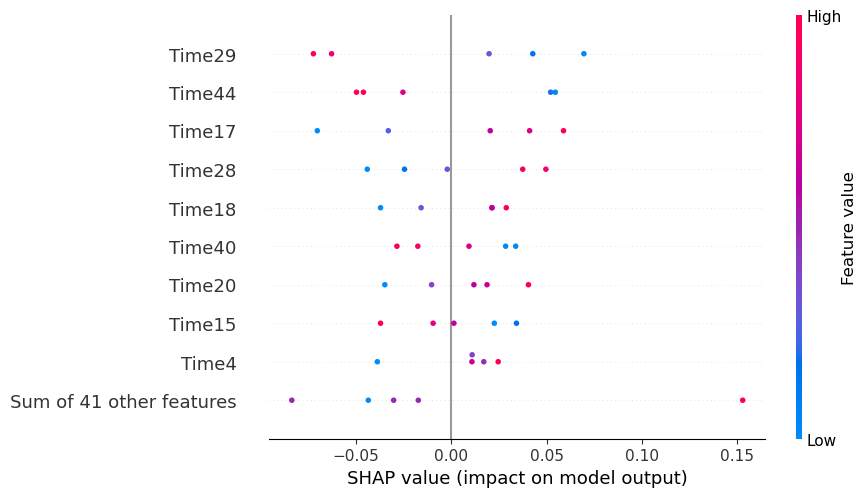

CPU times: user 19.2 s, sys: 3.65 s, total: 22.8 s
Wall time: 18.4 s


In [37]:
%%time
time_samples = 50
max_samples = 5

ds = CustomDataset('Mona Lisa', 'alpha', DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
X = ds.dataframe
X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]

samples=samples.astype(float, errors="ignore")


background = samples.iloc[:, :time_samples]

#print(type(background))

#background=np.array(background, dtype=float)

print(type(background))


values = samples.iloc[:, time_samples+1:2*time_samples+1]

print(type(values))

#values=np.array(values, dtype=float)

#print(type(values))

# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background, max_evals=samples.shape[1]*2+1)

print(e)

#shap_values = e(values)

shap_values = e(background)

#print(shap_values)

shap.plots.beeswarm(shap_values)

In [38]:
pd.__version__

'2.1.4'

In [39]:
shap.__version__

'0.45.1'

In [40]:
np.__version__

'1.26.4'

In [41]:
torch.__version__

'2.3.1+cu118'

In [42]:
import sys
print(sys.version)

3.11.7 (main, Dec 15 2023, 18:12:31) [GCC 11.2.0]


In [43]:
!python3 -V 

Python 3.11.7


In [44]:
import tensorflow as ft

ModuleNotFoundError: No module named 'tensorflow'

In [54]:
%%time
time_samples = 50
max_samples = 3100

ds = CustomDataset('Mona Lisa', 'alpha', DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
X = ds.dataframe
X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]

samples=samples.astype(float, errors="ignore")


background = samples.iloc[:, :time_samples]

#print(type(background))

#background=np.array(background, dtype=float)

print(type(background))


values = samples.iloc[:, time_samples+1:2*time_samples+1]

print(type(values))

#values=np.array(values, dtype=float)

#print(type(values))

# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background, max_evals=samples.shape[1]*2+1)

print(e)

#shap_values = e(values)

shap_values = e(background)

#print(shap_values)

shap.plots.beeswarm(shap_values)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
shap.explainers.PermutationExplainer()


PermutationExplainer explainer:   1%|▏                             | 20/3100 [01:43<4:54:36,  5.74s/it]


KeyboardInterrupt: 

In [45]:
ds = CustomDataset('Mona Lisa', 'alpha', DATASET, True, max_samples)

In [53]:
len(ds)


3100

<class 'pandas.core.frame.DataFrame'>
shap.explainers.PermutationExplainer()


PermutationExplainer explainer: 11it [08:19, 49.96s/it]                                                


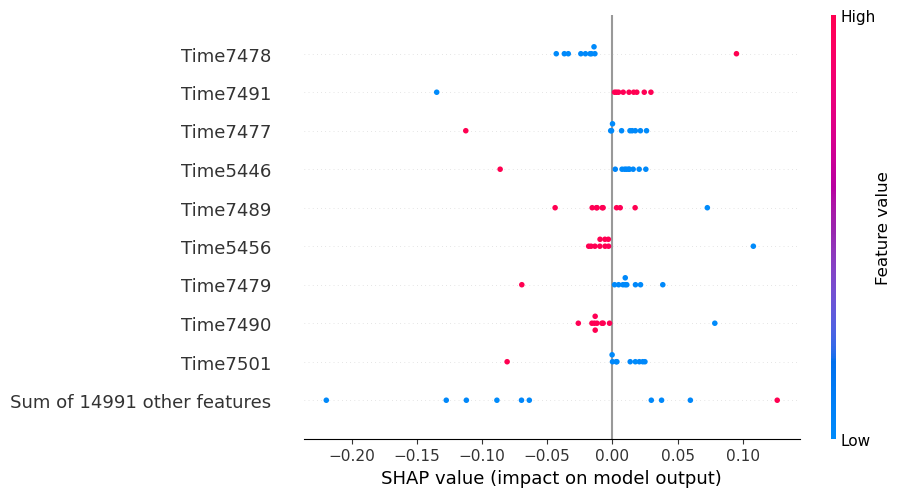

CPU times: user 33min 5s, sys: 14min 14s, total: 47min 20s
Wall time: 8min 39s


In [55]:
%%time
time_samples = 15000
max_samples = 10

ds = CustomDataset('Mona Lisa', 'alpha', DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
X = ds.dataframe
X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]

samples=samples.astype(float, errors="ignore")


background = samples.iloc[:, :time_samples]

#print(type(background))

#background=np.array(background, dtype=float)

print(type(background))


#values = samples.iloc[:, time_samples+1:2*time_samples+1]

#print(type(values))

#values=np.array(values, dtype=float)

#print(type(values))

# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background, max_evals=samples.shape[1]*2+1)

print(e)

#shap_values = e(values)

shap_values = e(background)

#print(shap_values)

shap.plots.beeswarm(shap_values)

In [ ]:
%%time
time_samples = 15000
max_samples = 20

ds = CustomDataset('Mona Lisa', 'alpha', DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
X = ds.dataframe
X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]

samples=samples.astype(float, errors="ignore")


background = samples.iloc[:, :time_samples]

#print(type(background))

#background=np.array(background, dtype=float)

print(type(background))


#values = samples.iloc[:, time_samples+1:2*time_samples+1]

#print(type(values))

#values=np.array(values, dtype=float)

#print(type(values))

# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background, max_evals=samples.shape[1]*2+1)

#print(e)

#shap_values = e(values)

shap_values = e(background)

#print(shap_values)

shap.plots.beeswarm(shap_values)

In [ ]:
1